In [2]:
pip install yfinance

  Obtaining dependency information for yfinance from https://files.pythonhosted.org/packages/5f/12/7efaf78fcf63711ad7271704dd22963b4cbe05d95d89b9865a1c5c0bad6f/yfinance-1.7.0-py3-none-any.whl.metadata
  Obtaining dependency information for curl_cffi>=0.15 from https://files.pythonhosted.org/packages/65/b0/b3dd929480f419f8aa921860afb44e15d2a22fd0be5c545296b9db865aa3/curl_cffi-0.16.2-cp310-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata
  Obtaining dependency information for multitasking>=0.0.7 from https://files.pythonhosted.org/packages/d3/1c/24dbf69b247f287401c904a396233a43c89fd4fb9b7cd2e50e430e9cd57c/multitasking-0.0.13-py3-none-any.whl.metadata
  Obtaining dependency information for peewee>=3.16.2 from https://files.pythonhosted.org/packages/69/28/1ed7ca6ec0b45d0209346fb82d7145a5abf8fd9bdca6bcb75cb868601f43/peewee-4.4.0-py3-none-any.whl.metadata
  Obtaining dependency information for cffi>=2.0.0 from https://files.pythonhosted.org/packages/f7/a4/4399daaf8f7dfee9d7c3327f

In [2]:
import pandas as pd 
import numpy as np 
import datetime
import matplotlib.pyplot as plt 
import yfinance as yf 

from datetime import date, datetime , time , timezone

In [3]:
def get_stock_data(ticker, start, end):
    data = yf.download(ticker, start=start, end=end, auto_adjust=False)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    data = data.loc[:, ~data.columns.duplicated()]
    data = data.reset_index()
    data["Ticker"] = ticker
    return data

In [4]:
ticker = 'DIS'
start = datetime(2025, 1, 1)
end = datetime.today()

In [5]:
d = get_stock_data(ticker, start, end)
d.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2025-01-02,108.774353,110.820000,112.199997,110.169998,111.699997,5688100,DIS
1,2025-01-03,109.108078,111.160004,111.540001,110.180000,111.370003,5393100,DIS
2,2025-01-06,109.000114,111.050003,112.849998,110.870003,111.470001,6274400,DIS
3,2025-01-07,109.333832,111.389999,113.739998,111.290001,112.150002,7878800,DIS
4,2025-01-08,107.733917,109.760002,111.110001,108.639999,111.000000,7805300,DIS


In [6]:
d = d.pivot(index = 'Date', columns = 'Ticker', values = 'Close')
d.head()

Ticker,DIS
Date,
2025-01-02,110.820000
2025-01-03,111.160004
2025-01-06,111.050003
2025-01-07,111.389999
2025-01-08,109.760002


In [ ]:
SPY = get_stock_data('SPY', start, end)
IYW = get_stock_data('IYW', start, end)
VT = get_stock_data('VT', start, end)
DBA = get_stock_data('DBA', start, end)
TLT = get_stock_data('TLT', start, end)
PDBC = get_stock_data('PDBC', start, end)
IAU = get_stock_data('IAU', start, end)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
$PDBC: possibly delisted; no price data found  (1d 2025-01-01 00:00:00 -> 2026-08-31 10:56:49.211617)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['PDBC']: possibly delisted; no price data found  (1d 2025-01-01 00:00:00 -> 2026-08-31 10:56:49.211617)
[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 415 entries, 0 to 414
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       415 non-null    datetime64[ns]
 1   Adj Close  415 non-null    float64       
 2   Close      415 non-null    float64       
 3   High       415 non-null    float64       
 4   Low        415 non-null    float64       
 5   Open       415 non-null    float64       
 6   Volume     415 non-null    int64         
 7   Ticker     415 non-null    object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 26.1+ KB


In [8]:
SPY.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 415 entries, 0 to 414
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       415 non-null    datetime64[ns]
 1   Adj Close  415 non-null    float64       
 2   Close      415 non-null    float64       
 3   High       415 non-null    float64       
 4   Low        415 non-null    float64       
 5   Open       415 non-null    float64       
 6   Volume     415 non-null    int64         
 7   Ticker     415 non-null    object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 26.1+ KB


In [10]:
SPY = SPY.reset_index().pivot(index = "Date", columns = "Ticker", values = "Close")
IYW = IYW.reset_index().pivot(index = "Date", columns = "Ticker", values = "Close")
VT = VT.reset_index().pivot(index = "Date", columns = "Ticker", values = "Close")
DBA = DBA.reset_index().pivot(index = "Date", columns = "Ticker", values = "Close")
TLT = TLT.reset_index().pivot(index = "Date", columns = "Ticker", values = "Close")
# PDBC = PDBC.reset_index().pivot(index = "Date", columns = "Ticker", values = "Close")
IAU = IAU.reset_index().pivot(index = "Date", columns = "Ticker", values = "Close")

KeyError: 'Ticker'

In [11]:
print(SPY.columns.tolist())
print(SPY.head())

['SPY']
Ticker             SPY
Date                  
2025-01-02  584.640015
2025-01-03  591.950012
2025-01-06  595.359985
2025-01-07  588.630005
2025-01-08  589.489990


In [ ]:

import pandas as pd 
import numpy as np 
import datetime
import matplotlib.pyplot as plt 
import yfinance as yf 

from datetime import date, datetime , time , timezone
def get_stock_data(ticker, start, end):
    data = yf.download(ticker, start=start, end=end, auto_adjust=False)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    data = data.loc[:, ~data.columns.duplicated()]
    data = data.reset_index()
    data["Ticker"] = ticker
    return data

ticker = 'DIS'
start = datetime(2025, 1, 1)
end = datetime.today()

d = get_stock_data(ticker, start, end)
d.head()

d = d.pivot(index = 'Date', columns = 'Ticker', values = 'Close')
d.head()

SPY = get_stock_data('SPY', start, end)
IYW = get_stock_data('IYW', start, end)
VT = get_stock_data('VT', start, end)
DBA = get_stock_data('DBA', start, end)
TLT = get_stock_data('TLT', start, end)
PDBC = get_stock_data('PDBC', start, end)
IAU = get_stock_data('IAU', start, end)

SPY.info()

SPY = SPY.reset_index().pivot(index = "Date", columns = "Ticker", values = "Close")
IYW = IYW.reset_index().pivot(index = "Date", columns = "Ticker", values = "Close")
VT = VT.reset_index().pivot(index = "Date", columns = "Ticker", values = "Close")
DBA = DBA.reset_index().pivot(index = "Date", columns = "Ticker", values = "Close")
TLT = TLT.reset_index().pivot(index = "Date", columns = "Ticker", values = "Close")
PDBC = PDBC.reset_index().pivot(index = "Date", columns = "Ticker", values = "Close")
IAU = IAU.reset_index().pivot(index = "Date", columns = "Ticker", values = "Close")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 415 entries, 0 to 414
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       415 non-null    datetime64[ns]
 1   Adj Close  415 non-null    float64       
 2   Close      415 non-null    float64       
 3   High       415 non-null    float64       
 4   Low        415 non-null    float64       
 5   Open       415 non-null    float64       
 6   Volume     415 non-null    int64         
 7   Ticker     415 non-null    object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 26.1+ KB


In [ ]:
# import pandas as pd
# import numpy as np
# import datetime
# import matplotlib.pyplot as plt
# import yfinance as yf

# from datetime import datetime

# # --- Config ---
# tickers = ["DIS", "SPY", "IYW", "VT", "DBA", "TLT", "PDBC", "IAU"]
# start = datetime(2025, 1, 1)
# end = datetime.today()

# # --- Download all tickers at once ---
# raw = yf.download(tickers, start=start, end=end, auto_adjust=False)

# # Extract just the Close prices -> one column per ticker, Date as index
# prices = raw["Close"]

# # Optional: drop rows where everything is NaN (e.g. holidays not shared across tickers)
# prices = prices.dropna(how="all")

# print(prices.head())
# print(prices.info())

# # --- If you need individual series later, just slice columns ---
# SPY  = prices["SPY"]
# IYW  = prices["IYW"]
# VT   = prices["VT"]
# DBA  = prices["DBA"]
# TLT  = prices["TLT"]
# PDBC = prices["PDBC"]
# IAU  = prices["IAU"]
# DIS  = prices["DIS"]

[                       0%                       ]$TLT: possibly delisted; no price data found  (1d 2025-01-01 00:00:00 -> 2026-08-31 11:20:18.040684)
$VT: possibly delisted; no price data found  (1d 2025-01-01 00:00:00 -> 2026-08-31 11:20:18.040684)
[************          25%                       ]  2 of 8 completed$DBA: possibly delisted; no price data found  (1d 2025-01-01 00:00:00 -> 2026-08-31 11:20:18.040684)
[*********************100%***********************]  8 of 8 completed

3 Failed downloads:
['TLT', 'VT', 'DBA']: possibly delisted; no price data found  (1d 2025-01-01 00:00:00 -> 2026-08-31 11:20:18.040684)


Ticker      DBA         DIS        IAU         IYW   PDBC         SPY  TLT  VT
Date                                                                          
2025-01-02  NaN  110.820000  50.189999  159.550003  13.13  584.640015  NaN NaN
2025-01-03  NaN  111.160004  49.790001  162.369995  13.05  591.950012  NaN NaN
2025-01-06  NaN  111.050003  49.740002  164.869995  13.08  595.359985  NaN NaN
2025-01-07  NaN  111.389999  50.009998  161.100006  13.14  588.630005  NaN NaN
2025-01-08  NaN  109.760002  50.290001  161.039993  13.12  589.489990  NaN NaN
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 415 entries, 2025-01-02 to 2026-08-28
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DBA     0 non-null      float64
 1   DIS     415 non-null    float64
 2   IAU     415 non-null    float64
 3   IYW     415 non-null    float64
 4   PDBC    415 non-null    float64
 5   SPY     415 non-null    float64
 6   TLT     0 non-null     

In [ ]:
stock = pd.concat([SPY, IYW, VT, DBA, TLT, PDBC, IAU], axis=1, join = 'outer')

stock.head()



In [27]:
plt.style.use('ggplot')
stock.plot(figsize=(12, 6))
plt.show()

ValueError: Date ordinal -3234277.6586217405 converts to -6886-11-07T08:11:35.081632 (using epoch 1970-01-01T00:00:00), but Matplotlib dates must be between year 0001 and 9999.

<Figure size 1200x600 with 1 Axes>

[*********************100%***********************]  7 of 8 completed


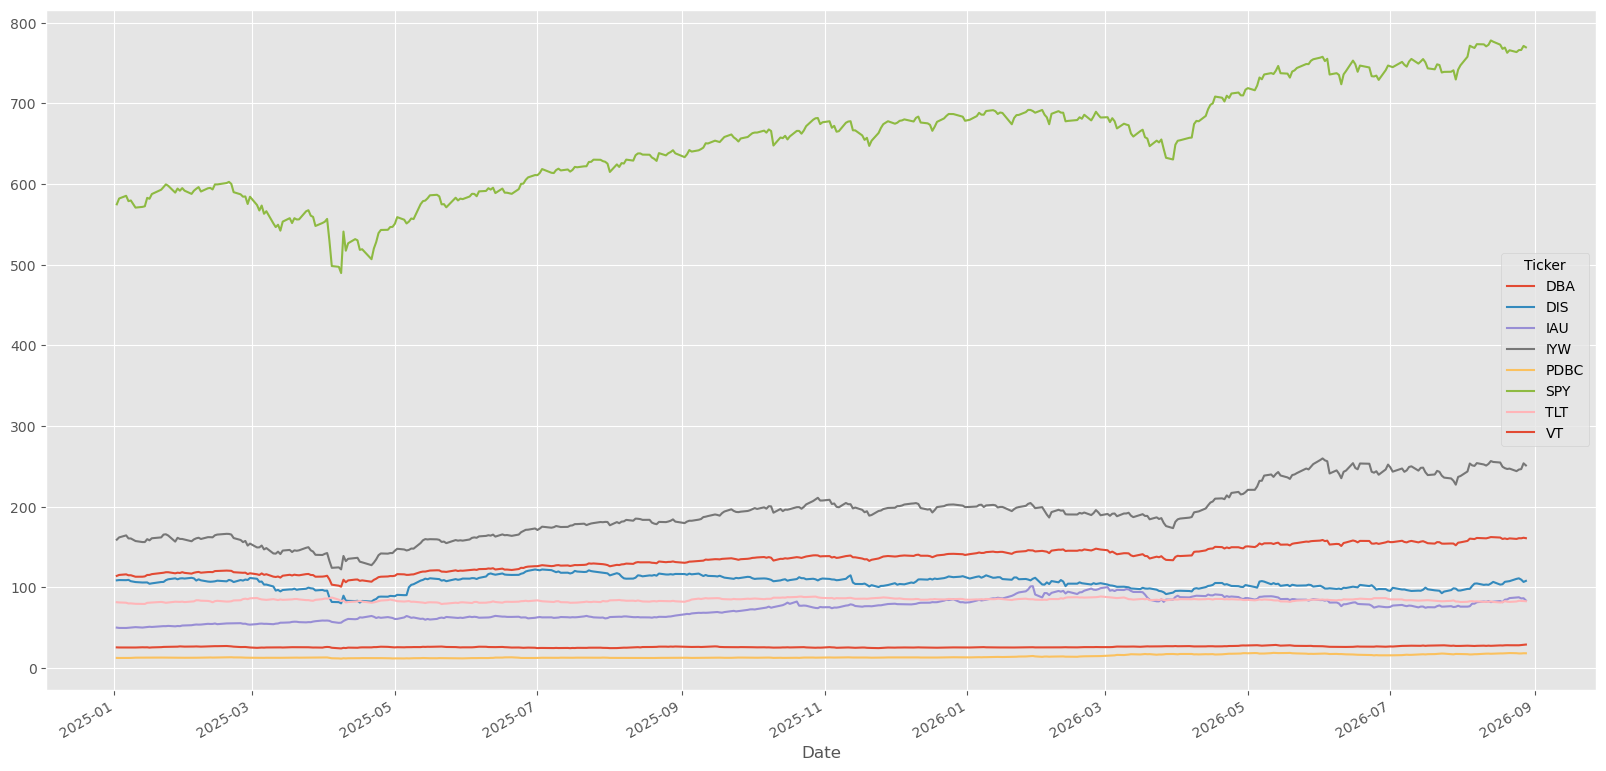

In [28]:
tickers = ["SPY", "IYW", "VT", "DBA", "TLT", "PDBC", "IAU", "DIS"]
stock = yf.download(tickers, start=start, end=end)["Close"]
stock.plot(figsize=(20, 10))
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

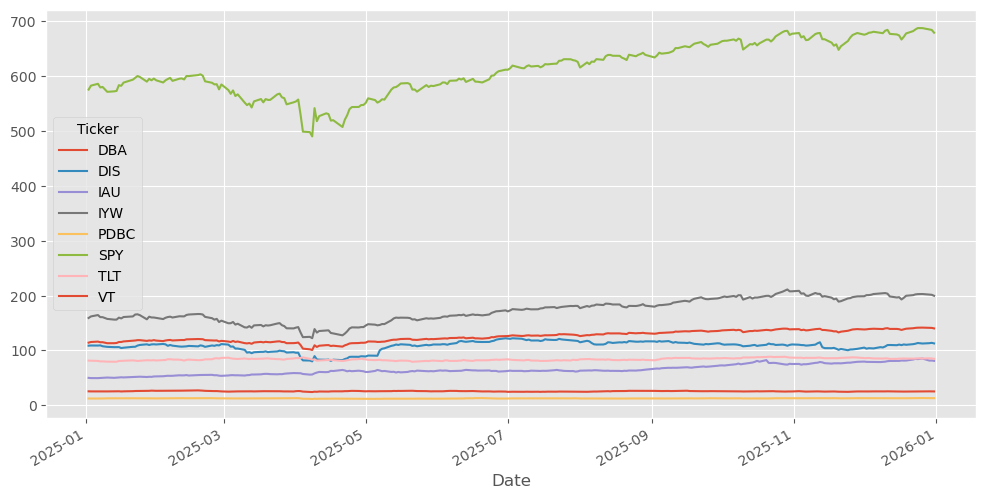

In [30]:
macro_shock = stock.loc['2025-01-01':'2025-12-31']
plt.style.use('ggplot')
macro_shock.plot(figsize=(12, 6))
plt.show


In [31]:
x = macro_shock.index
s_y = macro_shock[['SPY']]
i_y = macro_shock[['IAU']]
d_y = macro_shock[['DBA']]
t_y = macro_shock[['TLT']]

AttributeError: 'numpy.ndarray' object has no attribute 'tick_params'

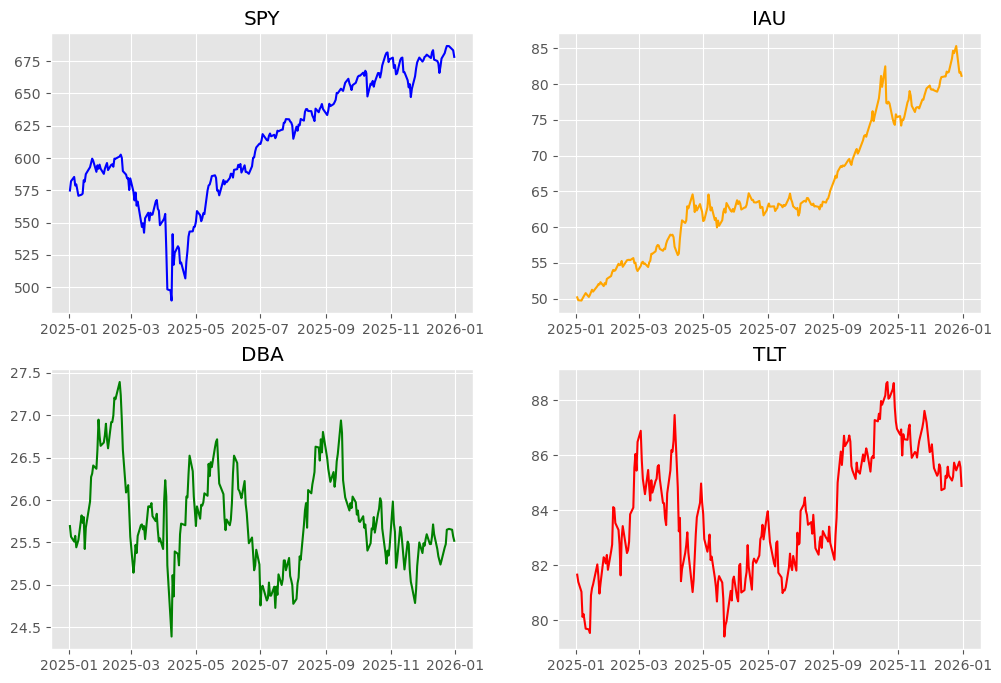

In [32]:
import matplotlib.pyplot as plt

fig , axs = plt.subplots(2, 2, figsize=(12, 8))
axs[0, 0].plot(x, s_y, color='blue')
axs[0, 0].set_title('SPY')
axs[0, 1].plot(x, i_y, color='orange')
axs[0, 1].set_title('IAU')
axs[1, 0].plot(x, d_y, color='green')
axs[1, 0].set_title('DBA')
axs[1, 1].plot(x, t_y, color='red')
axs[1, 1].set_title('TLT')

for ax in axs:
    ax.tick_params(axis='x', rotation=45)
fig.suptitle('Macro Shock')